# EDA (Exploratory Data Analysis)

**Esta EDA funciona para descubrir patrones y problemas iniciales:**
- Resúmenes estadísticos.
- Visualizaciones iniciales para identificar tendencias o anomalías.
- Correlaciones entre variables.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

**1. Cargar la base de datos**

In [2]:
ruta = os.path.join('..', 'Data', 'TouristAccommodationRaw26012026.csv')
df = pd.read_csv(ruta)


**2. Información general de la tabla**

In [3]:
df.head(5)

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019


In [4]:
#Numero de filas y Columnas
df.shape

(8000, 35)

In [5]:
# Revisar información de las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 8000 non-null   int64  
 1   name                         7997 non-null   object 
 2   description                  7946 non-null   object 
 3   host_id                      8000 non-null   int64  
 4   neighbourhood_name           8000 non-null   object 
 5   neighbourhood_district       4861 non-null   object 
 6   room_type                    8000 non-null   object 
 7   accommodates                 8000 non-null   int64  
 8   bathrooms                    7957 non-null   float64
 9   bedrooms                     7961 non-null   float64
 10  beds                         7992 non-null   float64
 11  amenities_list               7983 non-null   object 
 12  price                        7829 non-null   float64
 13  minimum_nights    

In [6]:
#Mirar las columnas
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date'],
      dtype='object')

In [7]:
#Mirar los duplicados
df.duplicated().sum()


np.int64(0)

In [8]:
#Valores unicos en cada columna
df.nunique()

apartment_id                   7693
name                           7714
description                    7736
host_id                        5888
neighbourhood_name              492
neighbourhood_district           61
room_type                         4
accommodates                     20
bathrooms                        13
bedrooms                         14
beds                             24
amenities_list                 7750
price                           392
minimum_nights                   41
maximum_nights                  135
has_availability                  1
availability_30                  31
availability_60                  61
availability_90                  91
availability_365                366
number_of_reviews               319
first_review_date              1938
last_review_date               1476
review_scores_rating             46
review_scores_accuracy            9
review_scores_cleanliness         9
review_scores_checkin             8
review_scores_communication 

**3. Descripción estadística**

In [9]:
# Resumen estadístico de las columnas numéricas
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
apartment_id,8000.0,1.696576e+07,8.733607e+06,11964.0,10762147.00,18075218.5,2.362542e+07,32423292.0
host_id,8000.0,7.086559e+07,6.575185e+07,10704.0,11968135.25,48353053.0,1.184978e+08,336524176.0
accommodates,8000.0,4.327000e+00,2.591990e+00,1.0,2.00,4.0,6.000000e+00,29.0
bathrooms,7957.0,1.598969e+00,9.837360e-01,0.0,1.00,1.0,2.000000e+00,12.0
bedrooms,7961.0,1.953147e+00,1.290257e+00,0.0,1.00,2.0,3.000000e+00,16.0
beds,7992.0,2.971346e+00,2.289586e+00,0.0,1.00,2.0,4.000000e+00,30.0
price,7829.0,1.007751e+03,8.443474e+02,60.0,450.00,750.0,1.220000e+03,6071.0
minimum_nights,8000.0,4.571250e+00,1.180783e+01,1.0,1.00,2.0,4.000000e+00,365.0
maximum_nights,8000.0,7.612301e+02,4.979496e+02,1.0,62.00,1125.0,1.125000e+03,1125.0
availability_30,8000.0,1.239125e+01,1.152430e+01,0.0,0.00,10.0,2.400000e+01,30.0


In [10]:
# Resumen estadístico de las columnas no numéricas
df.describe(include = object).transpose()

,count,unique,top,freq
name,7997,7714,Beautiful two bedroom appartment with comunita...,4
description,7946,7736,This apartment is part of a nice and well kept...,4
neighbourhood_name,8000,492,la Dreta de l'Eixample,278
neighbourhood_district,4861,61,Centro,871
room_type,8000,4,Entire home/apt,5680
amenities_list,7983,7750,"TV,Wifi,Air conditioning,Kitchen,Elevator,Heat...",10
has_availability,7450,1,VERDADERO,7450
first_review_date,6386,1938,01/04/2018,27
last_review_date,6385,1476,08/03/2020,40
is_instant_bookable,8000,2,VERDADERO,4439


In [11]:
# Revisar valores faltantes
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "Cantidad de Valores Faltantes": missing,
    "Porcentaje de Valores Faltantes (%)": missing_percentage
})

,Cantidad de Valores Faltantes,Porcentaje de Valores Faltantes (%)
neighbourhood_district,3139,39.2375
review_scores_value,1711,21.3875
review_scores_location,1711,21.3875
review_scores_checkin,1710,21.3750
review_scores_accuracy,1705,21.3125
review_scores_communication,1701,21.2625
review_scores_cleanliness,1699,21.2375
review_scores_rating,1696,21.2000
last_review_date,1615,20.1875
reviews_per_month,1614,20.1750


**Visualización Porcentaje de valores faltantes por columna**

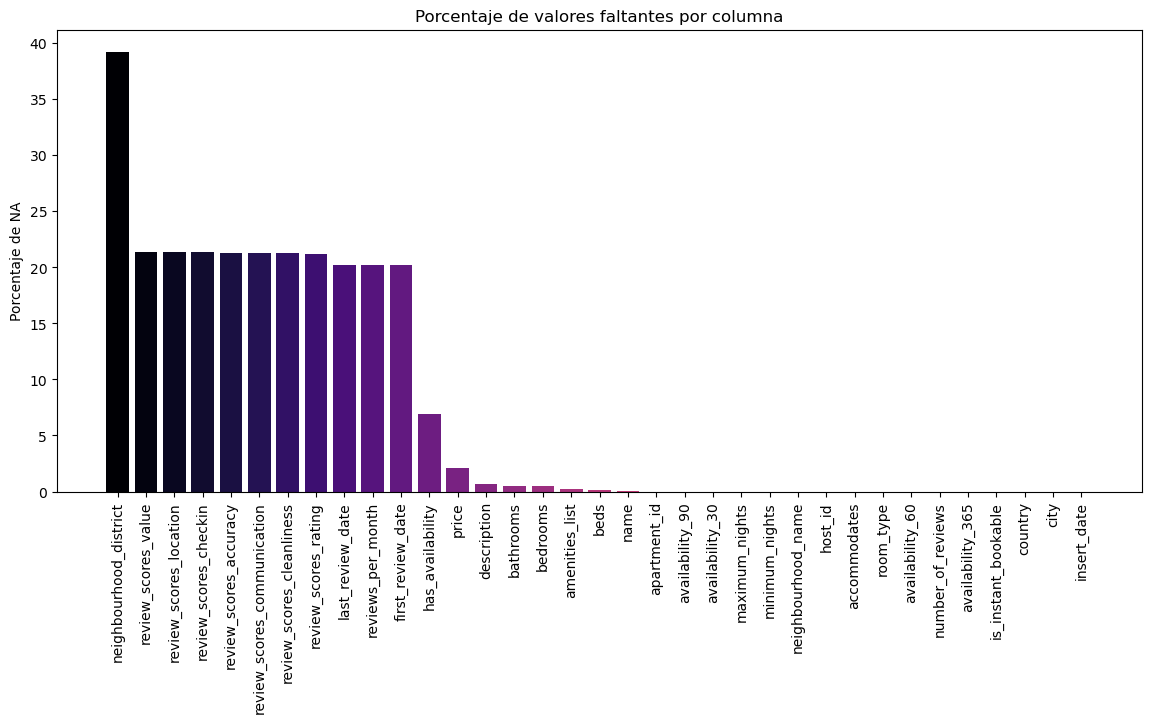

In [12]:
colors = cm.magma(np.linspace(0, 1, len(missing_percentage)))

plt.figure(figsize=(14,6))
plt.bar(missing_percentage.index, missing_percentage.values, color=colors)
plt.xticks(rotation=90)
plt.ylabel("Porcentaje de NA")
plt.title("Porcentaje de valores faltantes por columna")
plt.show()


**Gráfico para conocer la distribución de las variables númericas:**
- Es normal.
- Sesgada.
- Múltiples picos .
- Valores Extremos

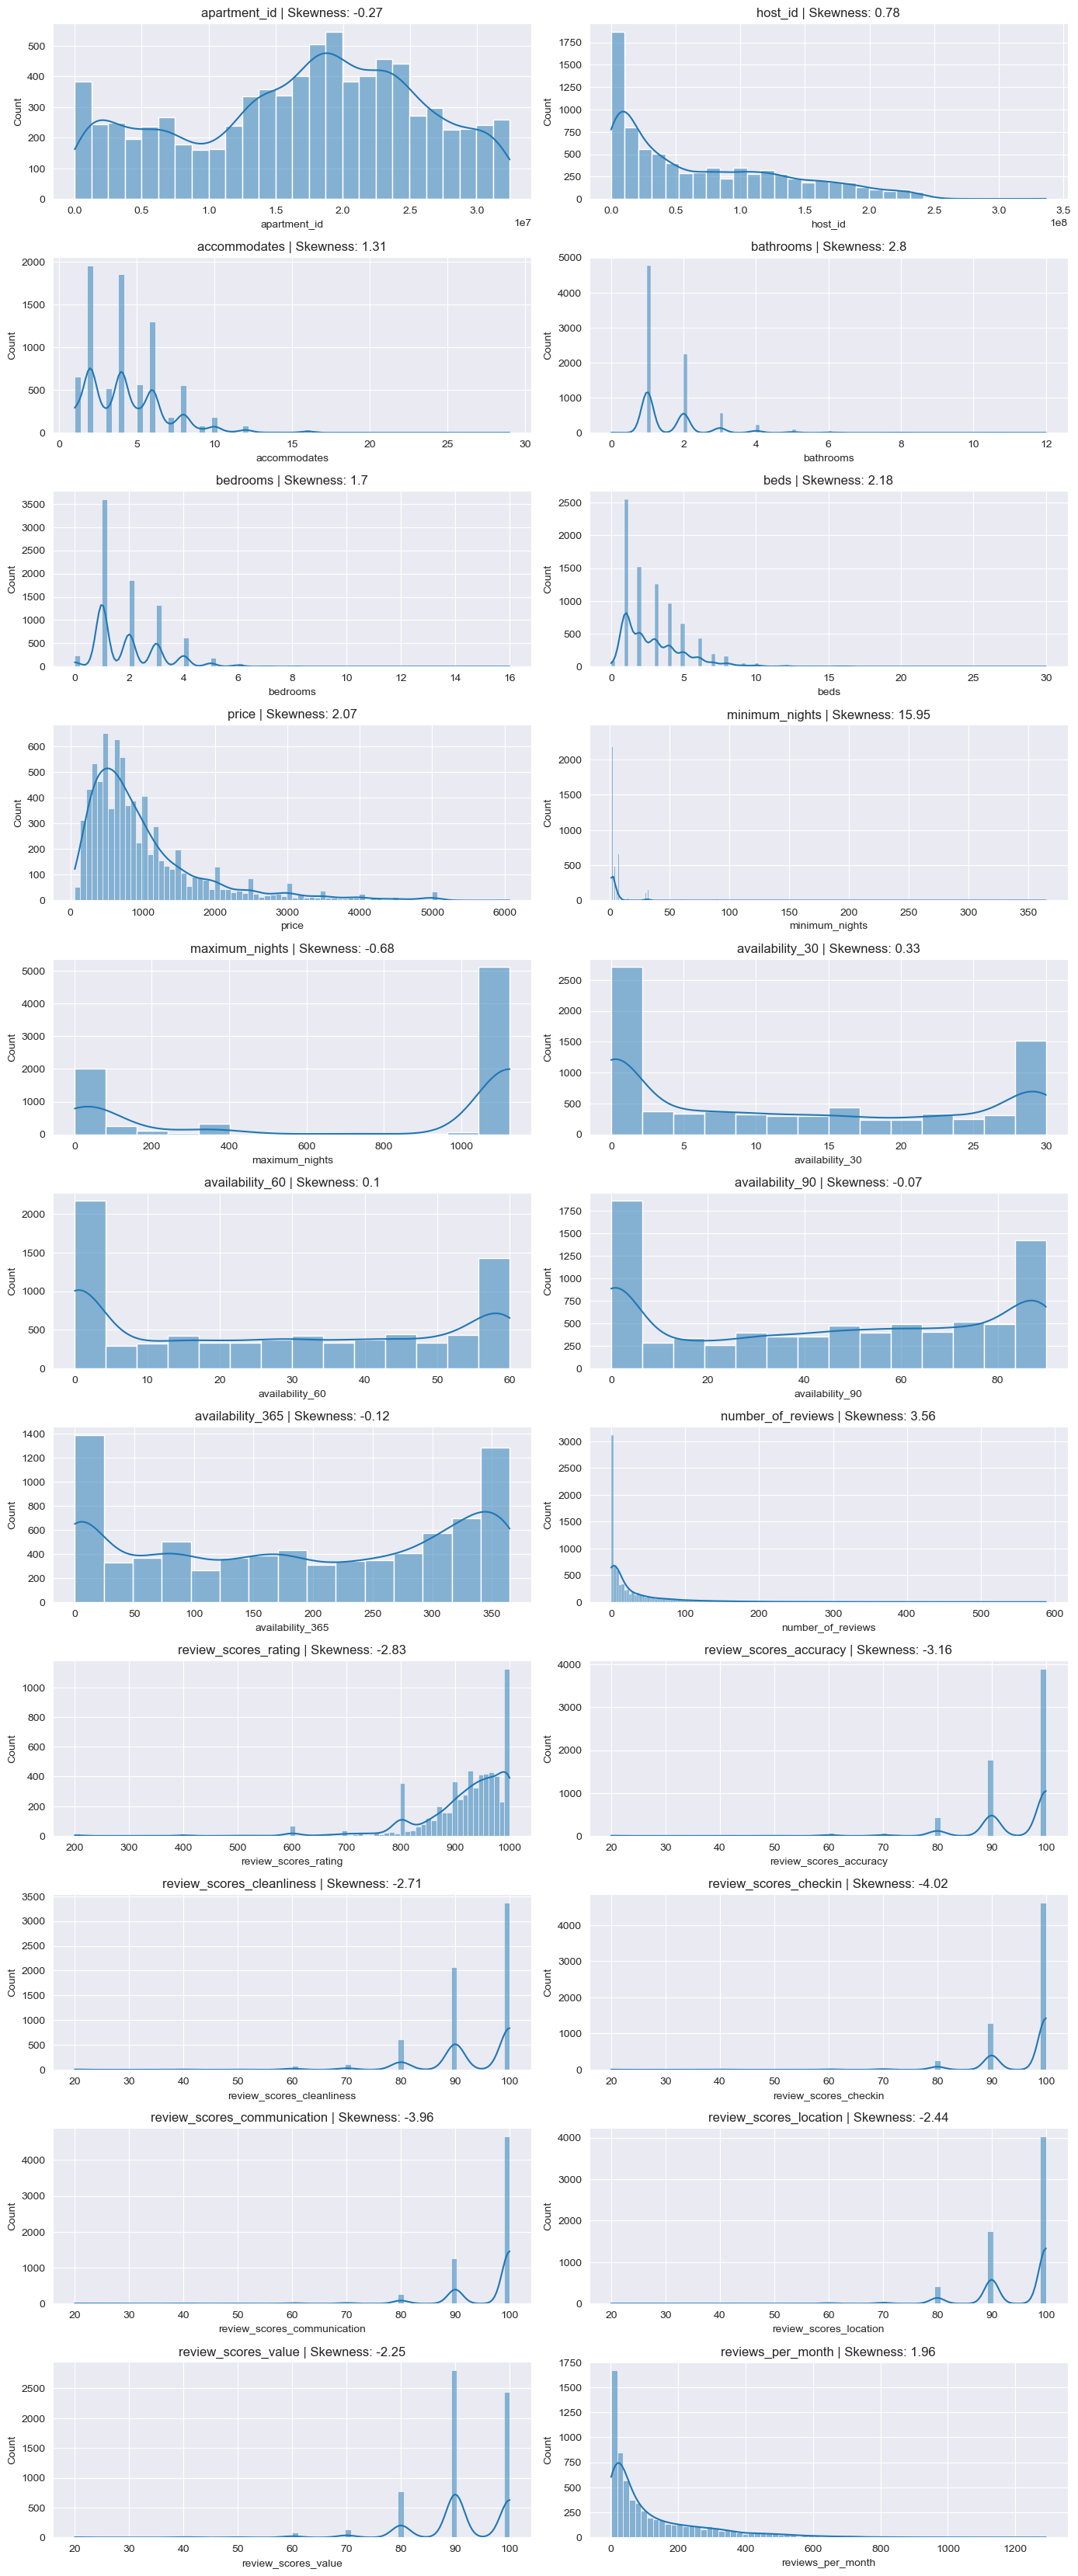

In [13]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

**Visualización de las varibles categoricas**

In [14]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns
print(len(categorical_columns), "columnas categóricas para visualizar.")


13 columnas categóricas para visualizar.


In [15]:
categorical_columns

Index(['name', 'description', 'neighbourhood_name', 'neighbourhood_district',
       'room_type', 'amenities_list', 'has_availability', 'first_review_date',
       'last_review_date', 'is_instant_bookable', 'country', 'city',
       'insert_date'],
      dtype='object')

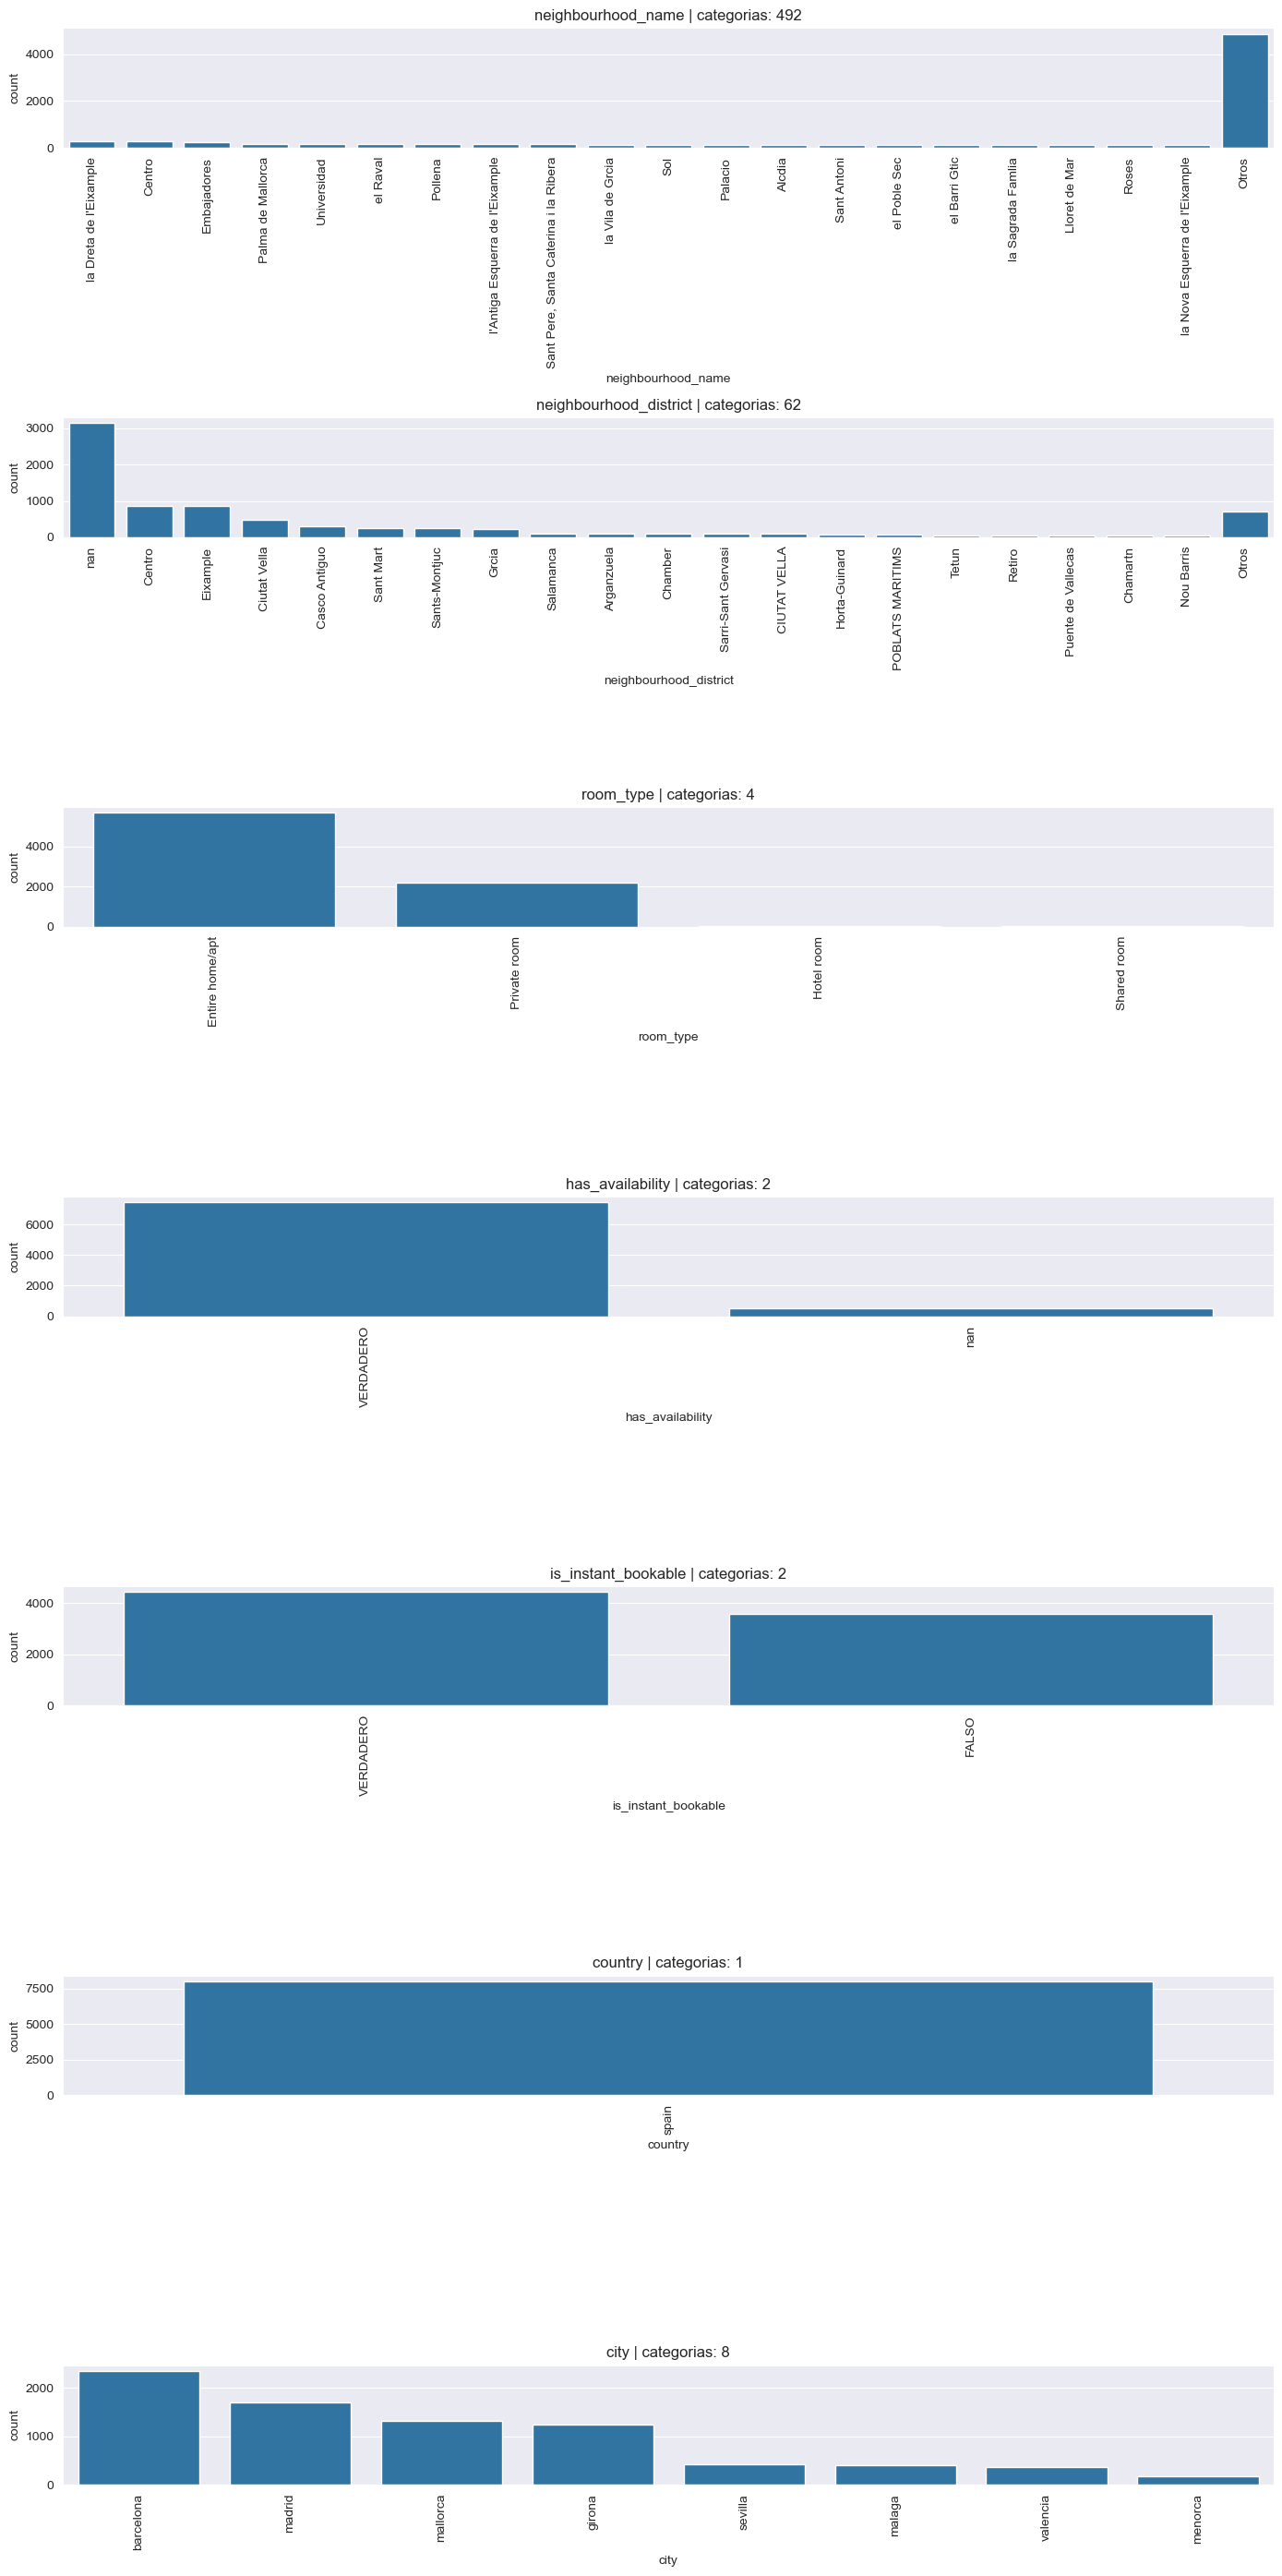

In [16]:
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("darkgrid")

categorical_to_plot = [
    'neighbourhood_name',
    'neighbourhood_district',
    'room_type',
    'has_availability',
    'is_instant_bookable',
    'country',
    'city'
]

plt.figure(figsize=(14, len(categorical_to_plot) * 4))

for idx, col in enumerate(categorical_to_plot, 1):
    plt.subplot(len(categorical_to_plot), 1, idx)
    
    # Convertir a str y eliminar caracteres raros
    df[col] = df[col].astype(str).str.encode('ascii', 'ignore').str.decode('ascii')
    
    # Agrupar menos frecuentes en 'Otros' si hay más de 20 categorías
    if df[col].nunique() > 20:
        top_categories = df[col].value_counts().nlargest(20).index
        new_col = df[col].apply(lambda x: x if x in top_categories else 'Otros')
    else:
        new_col = df[col]
    
    # Ordenar para que 'Otros' quede al final
    counts = new_col.value_counts()
    order = counts.index.drop('Otros') if 'Otros' in counts.index else counts.index
    if 'Otros' in counts.index:
        order = order.append(pd.Index(['Otros']))
    
    sns.countplot(
        data=df,
        x=new_col,
        order=order
    )
    
    plt.xticks(rotation=90)
    plt.title(f"{col} | categorias: {df[col].nunique()}")
    
plt.tight_layout()
plt.show()


In [17]:
categorical_to_plot = [
    'neighbourhood_name',
    'neighbourhood_district',
    'room_type',
    'has_availability',
    'is_instant_bookable',
    'city'
]

# Imprimir cuántas columnas tienes
print(len(categorical_to_plot), "columnas categóricas para visualizar.")

# Por ejemplo, para obtener solo esas columnas del DataFrame
df_subset = df[categorical_to_plot]


6 columnas categóricas para visualizar.


In [18]:
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date'],
      dtype='object')

**4.3 Visualización: boxplots para identificar outliers en columnas interesantes**

In [19]:
df.dtypes

apartment_id                     int64
name                            object
description                     object
host_id                          int64
neighbourhood_name              object
neighbourhood_district          object
room_type                       object
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
amenities_list                  object
price                          float64
minimum_nights                   int64
maximum_nights                   int64
has_availability                object
availability_30                  int64
availability_60                  int64
availability_90                  int64
availability_365                 int64
number_of_reviews                int64
first_review_date               object
last_review_date                object
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness

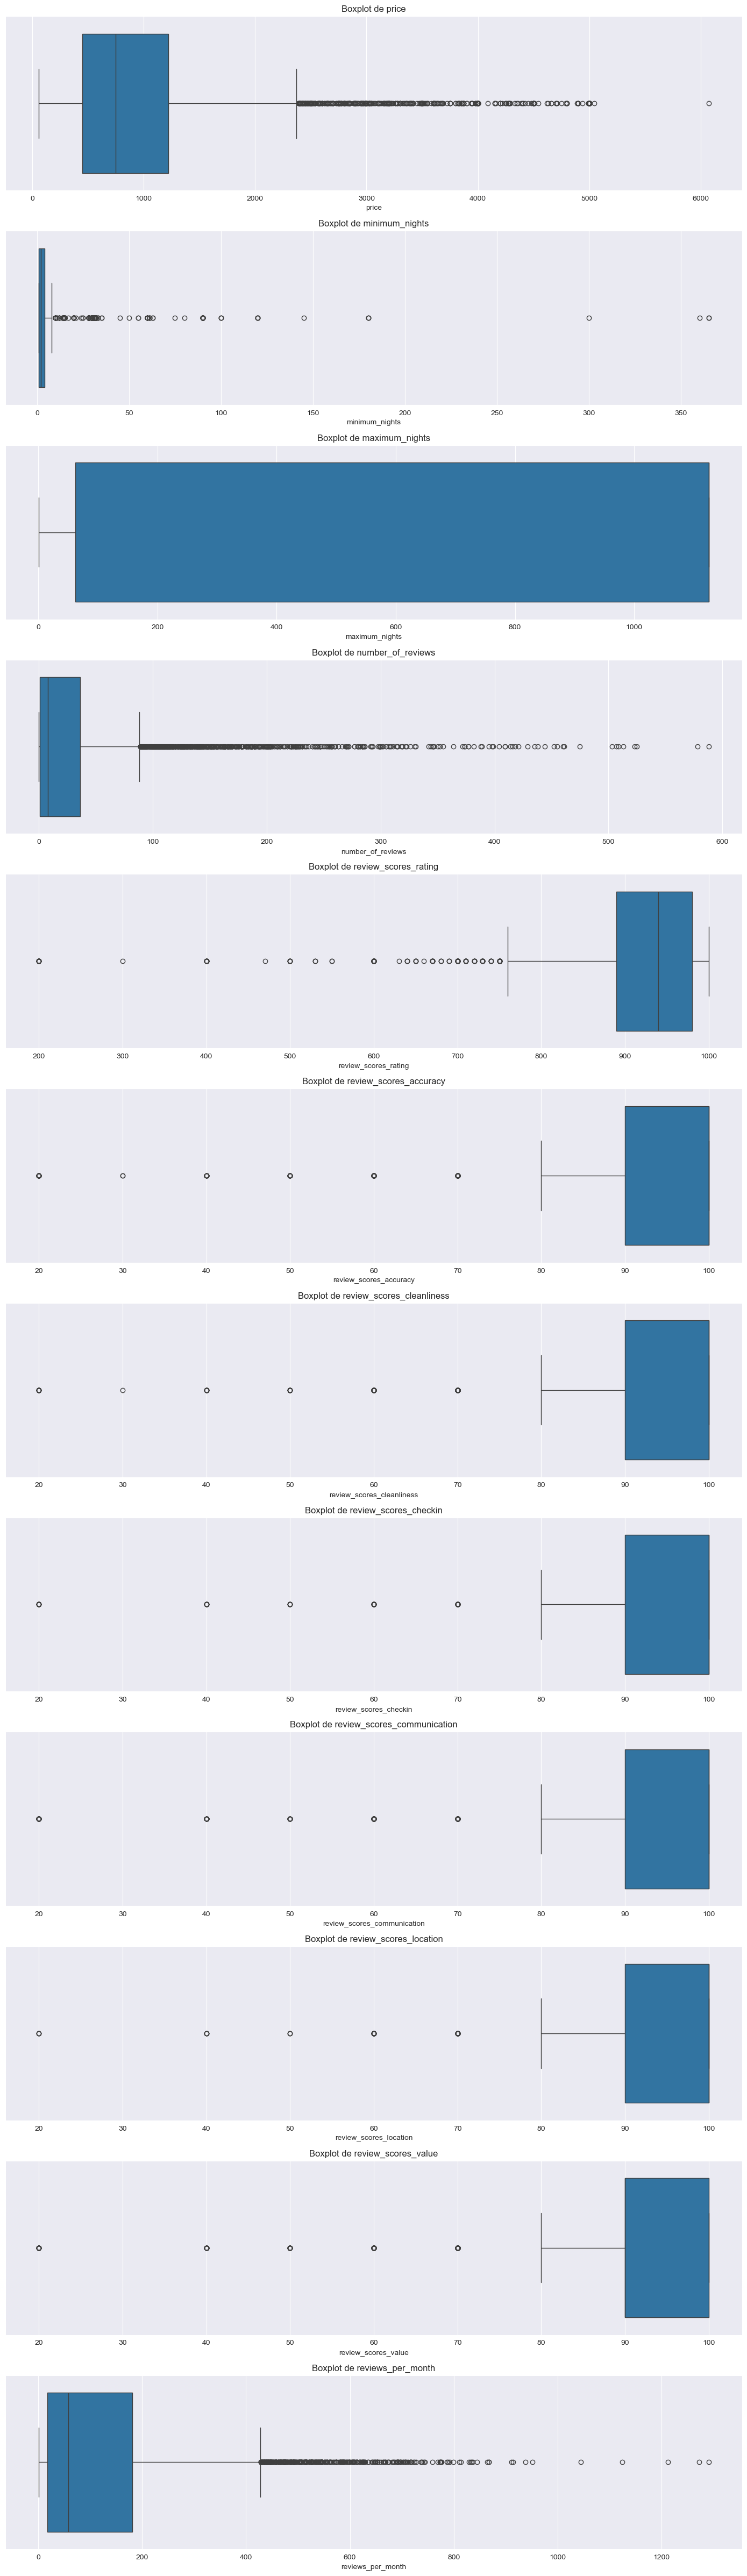

In [20]:
columns_to_plot = [
    'price','minimum_nights',
    'maximum_nights', 
    'number_of_reviews',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value','reviews_per_month',       
]

plt.figure(figsize=(14, len(columns_to_plot)*4))  

for i, col in enumerate(columns_to_plot, 1):  
    plt.subplot(len(columns_to_plot), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    
plt.tight_layout()
plt.show()

**Correlación de algunas variables númericas**

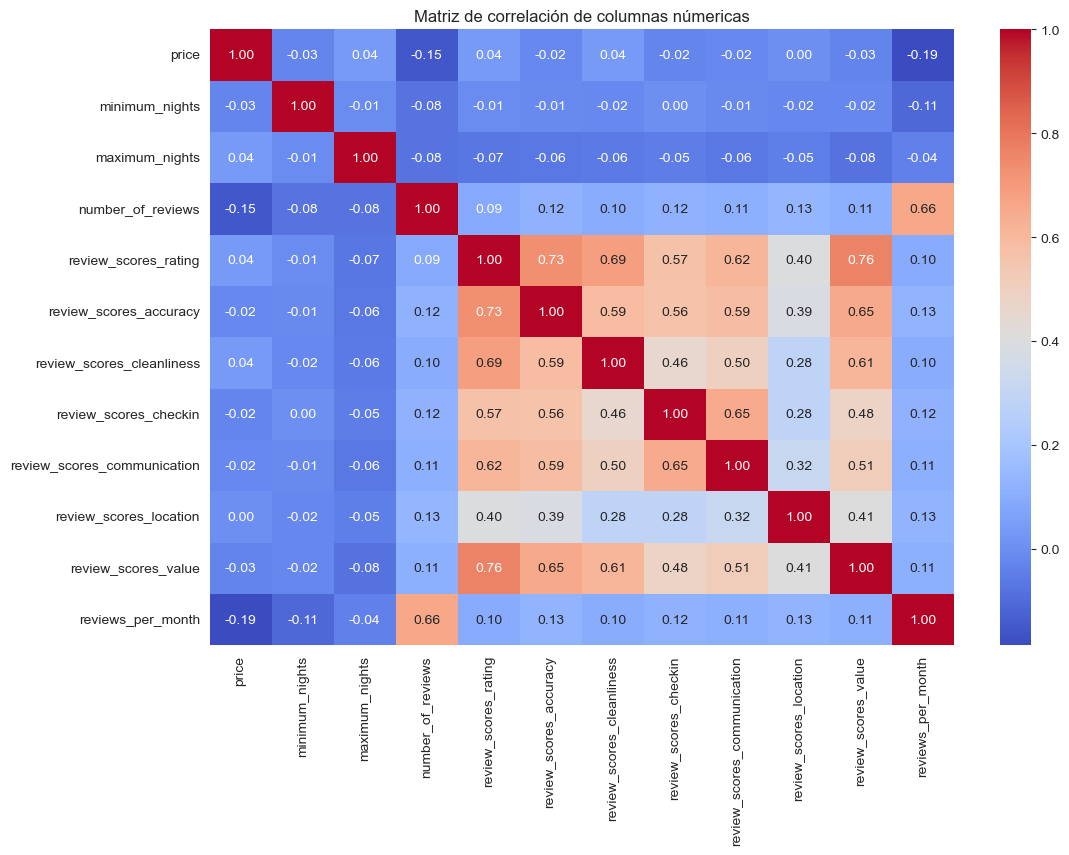

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[columns_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación de columnas númericas")
plt.show()